In [1]:
import pandas as pd, numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt, seaborn as sns
print("All imports OK")

All imports OK


In [2]:
X_train = pd.read_csv("C:\\Users\\hp\\Downloads\\CrediLens-main\\dataset\\data processed\\X_train.csv")
X_test  = pd.read_csv("C:\\Users\\hp\\Downloads\\CrediLens-main\\dataset\\data processed\\X_test.csv")
y_train = pd.read_csv("C:\\Users\\hp\\Downloads\\CrediLens-main\\dataset\\data processed\\y_train.csv").squeeze()
y_test  = pd.read_csv("C:\\Users\\hp\\Downloads\\CrediLens-main\\dataset\\data processed\\y_test.csv").squeeze()

# Sanity check
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(96658, 11) (96658,) (24165, 11) (24165,)


In [3]:
# helper function

def get_metrics(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy":  round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall":    round(recall_score(y_true, y_pred), 4),
        "F1-Score":  round(f1_score(y_true, y_pred), 4),
        "ROC-AUC":   round(roc_auc_score(y_true, y_prob), 4),
    }

results = []

In [4]:
# Train Logistic Regression

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

results.append(get_metrics("Logistic Regression", y_test, y_pred_lr, y_prob_lr))
print("\n--- Logistic Regression Results ---")
for key, value in results[-1].items():
    if key != "Model":
        print(f"  {key:<12}: {float(value):.4f}")


--- Logistic Regression Results ---
  Accuracy    : 0.7928
  Precision   : 0.2164
  Recall      : 0.7558
  F1-Score    : 0.3364
  ROC-AUC     : 0.8538


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [5]:
# Train Random Forest + note feature importances

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

results.append(get_metrics("Random Forest", y_test, y_pred_rf, y_prob_rf))

# Top 5 feature importances
import pandas as pd
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Top 5 features:\n", feat_imp.head(5))

Top 5 features:
 RevolvingUtilizationOfUnsecuredLines    0.219743
DebtRatio                               0.141252
MonthlyIncome                           0.130377
TotalPastDue                            0.128276
age                                     0.113774
dtype: float64


In [6]:
print("\n--- Random Forest Results ---")
for key, value in results[-1].items():
    if key != "Model":
        print(f"  {key:<12}: {float(value):.4f}")


--- Random Forest Results ---
  Accuracy    : 0.9314
  Precision   : 0.5213
  Recall      : 0.1531
  F1-Score    : 0.2366
  ROC-AUC     : 0.8240


In [7]:
# Train XGBoost (primary model)

# Handle class imbalance
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos

xgb = XGBClassifier(
    eval_metric='logloss',
    scale_pos_weight=spw,
    random_state=42
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

results.append(get_metrics("XGBoost (baseline)", y_test, y_pred_xgb, y_prob_xgb))

print("\n--- XGBoost (Baseline) Results ---")
for key, value in results[-1].items():
    if key != "Model":
        print(f"  {key:<12}: {float(value):.4f}")


--- XGBoost (Baseline) Results ---
  Accuracy    : 0.8261
  Precision   : 0.2410
  Recall      : 0.6992
  F1-Score    : 0.3585
  ROC-AUC     : 0.8440



===== Model Comparison =====
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.7928     0.2164  0.7558    0.3364   0.8538
Random Forest          0.9314     0.5213  0.1531    0.2366   0.8240
XGBoost (baseline)     0.8261     0.2410  0.6992    0.3585   0.8440


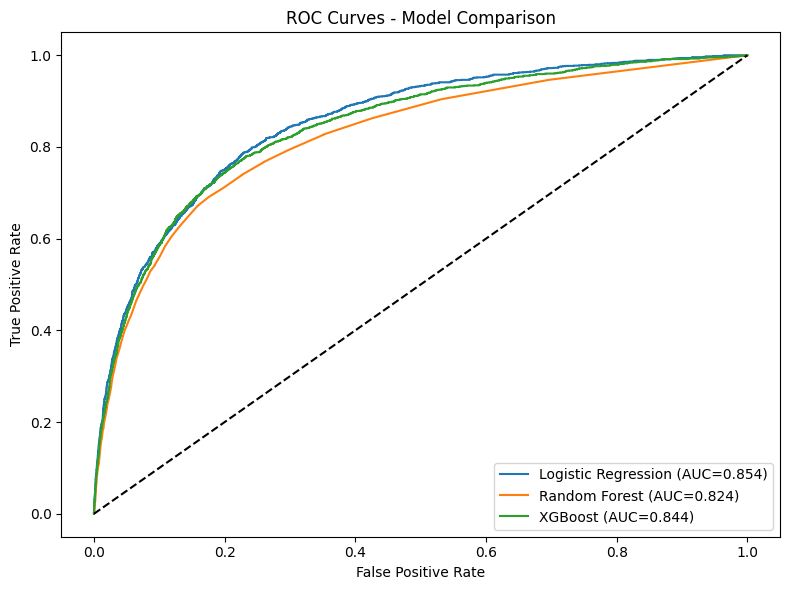

In [8]:
# comparison table and ROC curve plot

from sklearn.metrics import roc_curve, auc

# Save comparison table
results_df = pd.DataFrame(results)
results_df = results_df.set_index("Model")
results_df = results_df.apply(lambda x: x.map(lambda v: round(float(v), 4)))
print("\n===== Model Comparison =====")
print(results_df.to_string())

# ROC Curves
plt.figure(figsize=(8, 6))
for name, y_prob in [("Logistic Regression", y_prob_lr),
                      ("Random Forest", y_prob_rf),
                      ("XGBoost", y_prob_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()

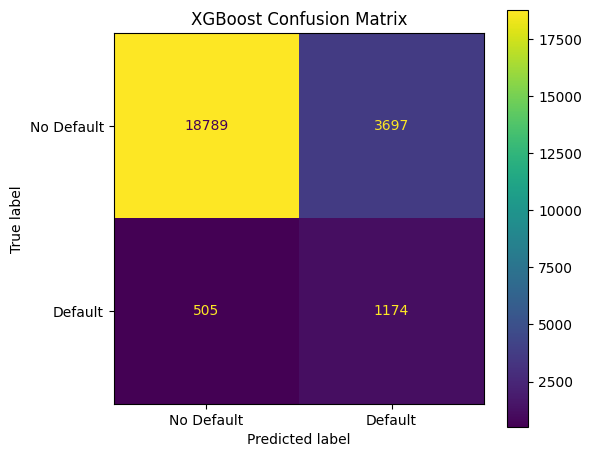

False Positives (wrongly flagged as default): 3697
False Negatives (missed actual defaults): 505


In [9]:
# Confusion matrix for XGBoost

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, ax=ax,
    display_labels=["No Default", "Default"])
ax.set_title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

# Analyse false rejections
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_xgb).ravel()
print(f"False Positives (wrongly flagged as default): {fp}")
print(f"False Negatives (missed actual defaults): {fn}")

In [10]:
# Hyperparameter tuning with RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators':      [100, 200],        # reduced from [100, 200, 300]
    'max_depth':         [3, 4, 5],         # reduced from [3, 4, 5, 6]
    'learning_rate':     [0.05, 0.1, 0.2],  # reduced from 4 values
    'subsample':         [0.8, 1.0],        # reduced from 3 values
    'colsample_bytree':  [0.8, 1.0],        # reduced from 3 values
}

xgb_tune = XGBClassifier(
    eval_metric='logloss',
    scale_pos_weight=spw,
    random_state=42
)

search = RandomizedSearchCV(
    xgb_tune, param_grid,
    scoring='roc_auc',
    n_iter=10,          # reduced from 30 — tries only 10 combinations
    cv=3,               # reduced from 5-fold to 3-fold
    random_state=42,
    n_jobs=1,           # ← most important change, uses only 1 core instead of all
    verbose=1
)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
best_xgb = search.best_estimator_

# Re-record metrics with tuned model
y_pred_best = best_xgb.predict(X_test)
y_prob_best = best_xgb.predict_proba(X_test)[:, 1]
print(get_metrics("XGBoost (tuned)", y_test, y_pred_best, y_prob_best))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
{'Model': 'XGBoost (tuned)', 'Accuracy': 0.7926, 'Precision': 0.2215, 'Recall': 0.7892, 'F1-Score': 0.3459, 'ROC-AUC': np.float64(0.8631)}


In [11]:
print("\nBest Parameters Found:")
for param, value in search.best_params_.items():
    print(f"  {param:<20}: {value}")

print("\n--- XGBoost (Tuned) Results ---")
for key, value in results[-1].items():
    if key != "Model":
        print(f"  {key:<12}: {float(value):.4f}")


Best Parameters Found:
  subsample           : 0.8
  n_estimators        : 100
  max_depth           : 3
  learning_rate       : 0.1
  colsample_bytree    : 0.8

--- XGBoost (Tuned) Results ---
  Accuracy    : 0.8261
  Precision   : 0.2410
  Recall      : 0.6992
  F1-Score    : 0.3585
  ROC-AUC     : 0.8440


In [13]:
import joblib, json, os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_xgb, "../models/xgb_baseline.pkl")
print("Model saved to models/xgb_baseline.pkl")

with open("../models/xgb_best_params.json", "w") as f:
    json.dump(search.best_params_, f, indent=2)
print("Best params saved to models/xgb_best_params.json")

Model saved to models/xgb_baseline.pkl
Best params saved to models/xgb_best_params.json
